# Acercamiento a Clusters con ``kMeans``

## Importación de librerías

En primera medida se importarán las librerías necesarias para la ejecución del código, entre ellas están `pandas` para el manejo de los datos, `numpy` para desarrollos matemáticos, `matplotlib.pyplot` para el manejo de gráficos, de `sklearn.cluster` se trae `kMeans` siendo este el algoritmo principal a usar y de `sklearn.preprocessing` se trae `StandardScaler` para estandarizar los datos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

## Importación del dataset a utilizar

En este caso se usó un dataset diseñado en casa con las medidas experimentales de altura, área y tiempo de tres objetos distintos. Se tomaron nueve áreas diferentes para cada objeto teniendo un total de veintisiete datos donde a cada uno se le asocia una altura y con ello un tiempo de caída diferente.

In [2]:
df = pd.read_excel("elementos.xlsx")
df

,Altura,Area,Tiempo,Cosa
0,110,10.500000,0.67,Palo
1,120,16.500000,0.60,Palo
2,130,22.500000,0.74,Palo
3,140,28.500000,0.75,Palo
4,150,34.500000,0.87,Palo
5,160,40.500000,0.80,Palo
6,170,46.500000,0.73,Palo
7,180,52.500000,0.74,Palo
8,190,58.500000,0.87,Palo
9,110,12.566371,0.47,Bola


### Selección de los datos de aprendizaje

Para los datos de aprendizaje se escogieron solamente dos columnas las cuales son la altura y el tiempo que demoró en caer, además se estandarizaron los datos para un mejor manejo a posterior, cabe destacar que las medidas de longitud y área están en $\textup{cm}$ y $\textup{cm}^{2}$ respectivamente, y las medidas de tiempo en segundos $\textup{s}$. Para ello se usaron métodos como `.drop()` para eliminar las columnas y `.StandardScaler().fit_transform()` para estandarizar los datos.

In [3]:
X = df.drop(df.columns[-1], axis=1).drop(df.columns[1], axis=1)
X_scaled = StandardScaler().fit_transform(X)

### Aplicación del algoritmo `kMeans` para clusters

A continuación, se aplicó el algoritmo `kMeans()` como ya es habitual para nosotros a la hora de usar un algoritmo de Machine Learning proveniente de scikit-learn. A su vez, se guardaron los resultados predichos en el mismo dataset original `df` junto a los centroides obtenidos en el arreglo `centroids`.

Algo de destacar es que al usar tres objetos distintos, se esperan tres clusters, así le decimos al algoritmo que seccione en tres clusters con una semilla fija gracias a `random_state`.

In [4]:
# Aplicar K-Means
kmeans = KMeans(n_clusters=4, random_state=42)
# Agregar las predicciones al DataFrame original
y_pred = kmeans.fit_predict(X_scaled)
df['Cluster'] = y_pred
# Guardar los centroides obtenidos
centroids = kmeans.cluster_centers_

### Gráfica de los resultados

Finalmente se graficaron los resultados obtenidos con un código sencillo de graficación donde se colocan en 3D tanto los clusters como los centroides obtenidos.

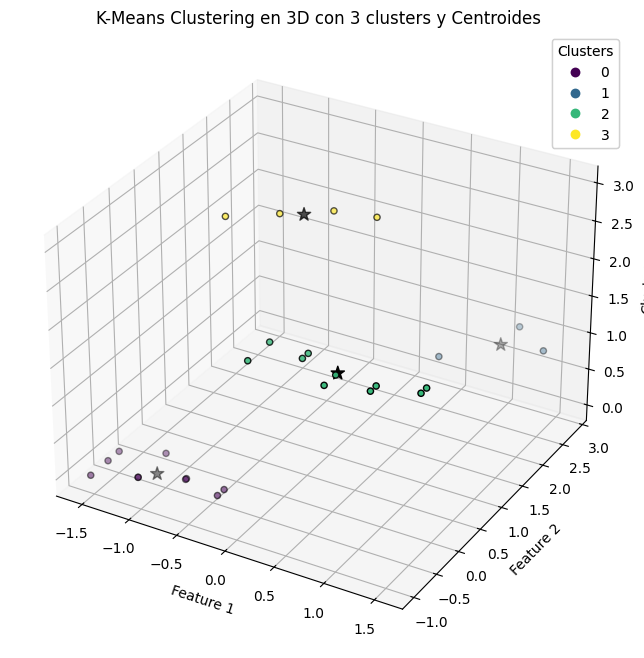

In [5]:
# Crear una figura 3D
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# Visualizar los resultados en un diagrama 3D para los puntos de datos
scatter = ax.scatter(X_scaled[:, 0], X_scaled[:, 1], y_pred, c=y_pred, cmap='viridis', edgecolors='k', label='Puntos de Datos')

# Visualizar los centroides
ax.scatter(centroids[:, 0], centroids[:, 1], np.arange(len(centroids)), marker='*', s=100, c='black', label='Centroides')

# Etiquetas de los ejes
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_zlabel('Cluster')

# Añadir barra de colores
legend = ax.legend(*scatter.legend_elements(), title="Clusters")
ax.add_artist(legend)

plt.title(f'K-Means Clustering en 3D con {3} clusters y Centroides')
plt.show()

## Conclusión

Nos podemos dar cuenta gracias a la gráfica que los clusters se generaron bastante bien separando los centroides de una manera muy buena, tanto así que si nosotros llamamos al DataFrame original, los palos de balso y las bolas de icopor presentan casi que los mismos clusters y esto se puede deber a que su caída libre para esas pequeñas medidas y tiempos es muy similar, sin embargo, para las hojas de papel se presenta una incertidumbre mayor y esto se puede generar debido a que las hojas de papel no siempre caen igual y dependen mucho de la forma en que se dejen caer, de la fricción con el aire, el área transversal respecto a la caída y demás.

In [6]:
df

,Altura,Area,Tiempo,Cosa,Cluster
0,110,10.500000,0.67,Palo,0
1,120,16.500000,0.60,Palo,0
2,130,22.500000,0.74,Palo,0
3,140,28.500000,0.75,Palo,0
4,150,34.500000,0.87,Palo,2
5,160,40.500000,0.80,Palo,2
6,170,46.500000,0.73,Palo,2
7,180,52.500000,0.74,Palo,2
8,190,58.500000,0.87,Palo,2
9,110,12.566371,0.47,Bola,0
